# Setup
In this notebook you'll be plotting bar plots using MatPlotLib and Seaborn.

Import necessary libraries and download the "spscientist/students-performance-in-exams" dataset from kaggle and read it to a Pandas DataFrame.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

#UNCOMMENT COMMANDS BELOW TO DOWNLOAD, only run unzip once or else the code will crash. once you unzip, just comment it back out

#! kaggle datasets download spscientist/students-performance-in-exams
#! unzip students-performance-in-exams.zip

Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100%|██████████████████████████████████████| 8.70k/8.70k [00:00<00:00, 14.5MB/s]

Archive:  students-performance-in-exams.zip
  inflating: StudentsPerformance.csv  


In [8]:
df = pd.read_csv("StudentsPerformance.csv")

In [9]:
df.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


# Bar Plots

(TASK 1): Using seaborn, make a countplot graphing the count of each ethnicity

Text(0.5, 1.0, 'Count of Each Race/Ethnicity')

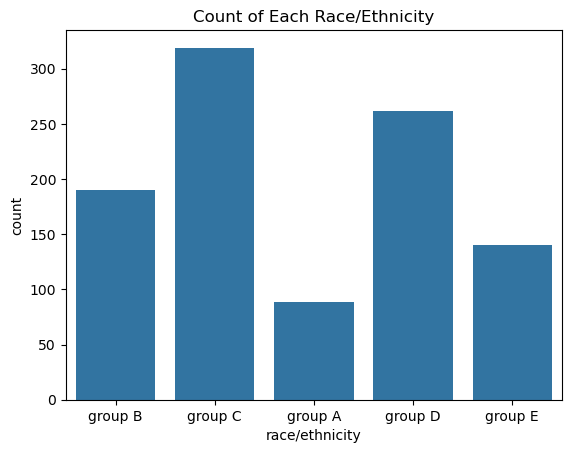

In [10]:
sns.countplot(data=df, x="race/ethnicity")
plt.title("Count of Each Race/Ethnicity")

(TASK 2):
Next, try doing the same thing with the matplotlib.

To get the counts of each race/ethnicity in a bar plot using the matplotlib method, we need to manually get the counts of each group. Try it yourself using a groupby. Make sure that you label the axes and title!

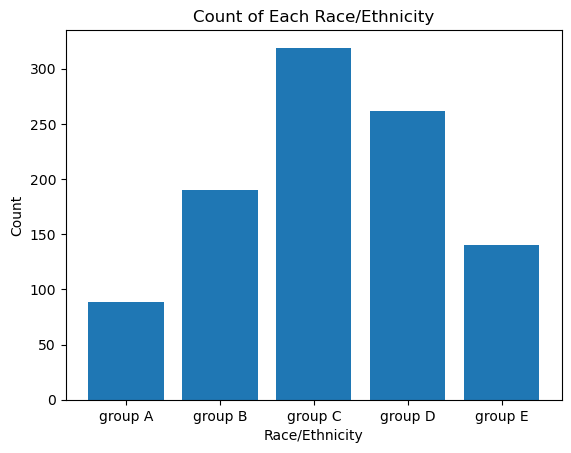

In [11]:
counts = df.groupby("race/ethnicity").count()
race = counts["gender"].reset_index().rename(columns={"gender": "counts"})
#TODO
plt.bar(race["race/ethnicity"], race["counts"])

plt.xlabel("Race/Ethnicity")
plt.ylabel("Count")
plt.title("Count of Each Race/Ethnicity")

plt.show()

The method you use to create a visualization is up to preference, although in more advanced data you may have a preference for one method over another. Keep both in mind because both are useful!

(TASK 3): Create a bar plot for the parental level of education (remember to label your axes and title).

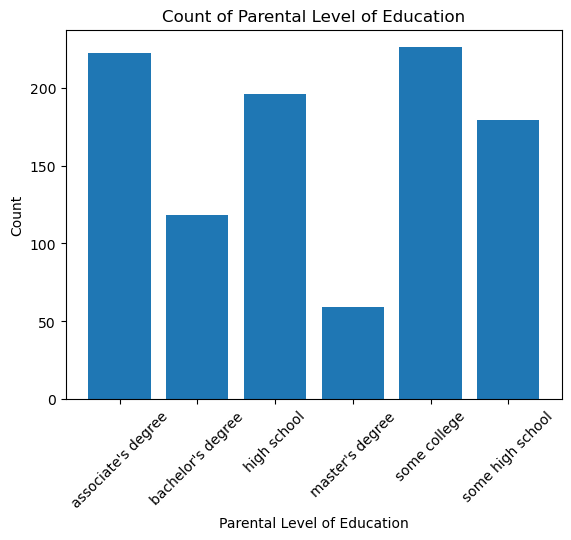

In [14]:
ed = df.groupby("parental level of education").count()
ed = ed["gender"].reset_index().rename(columns={"gender": "counts"})
#TODO
plt.bar(ed["parental level of education"], ed["counts"])

plt.xlabel("Parental Level of Education")
plt.ylabel("Count")
plt.title("Count of Parental Level of Education")

plt.xticks(rotation=45)
plt.show()

# Histograms/Density Curves/KDEs

(TASK 4): Now plot the distribution of math scores in a histogram using seaborn with a density curve laid on top of the histogram. You can use the histplot method for this.

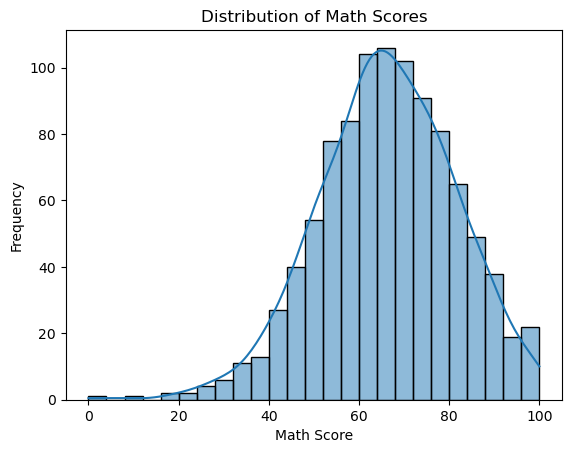

In [15]:
#TODO
sns.histplot(data=df, x="math score", kde=True)

plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.title("Distribution of Math Scores")

plt.show()

(TASK 5): Now using matplotlib. Plotting a density curve is a more difficult process here, so we'll skip doing it for now. The axes and title labels need to be added.

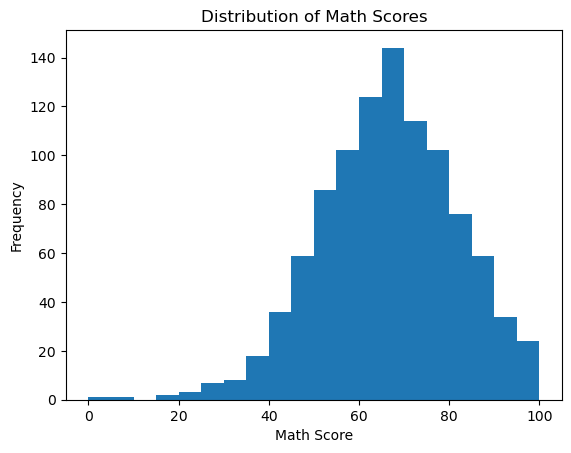

In [16]:
#TODO
plt.hist(df["math score"], bins=20)

plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.title("Distribution of Math Scores")

plt.show()

(TASK 6): We'll take some time to understand the skew, outliers, and mode of this histogram. What are the properties of this histogram?

The histogram is approximately symmetric and bell-shaped, resembling a normal distribution. The mode appears around 60-70. There is a slight left skew due to a few low scores, but overall the distribution is fairly balanced. There are minimal outliers, with only a few extreme low values.

Although we could visualize the quartiles within the histogram itself using colors and a legend, it comes out to a somewhat complicated process. If we don't have to include that aspect of visualization, we can do something similar in a box plot (covered later in the notebook)!

(TASK 7): We saw the density curve in the seaborn plot, try plotting just the density curve without the histogram.

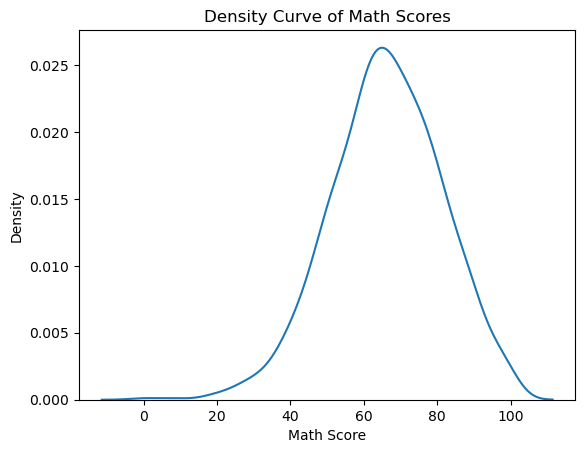

In [17]:
#TODO
sns.kdeplot(data=df, x="math score")

plt.xlabel("Math Score")
plt.ylabel("Density")
plt.title("Density Curve of Math Scores")

plt.show()

# Box Plots/Violin Plots

(TASK 8): Make a box plot of the math scores using matplotlib and seaborn. No need for a title on this plot.

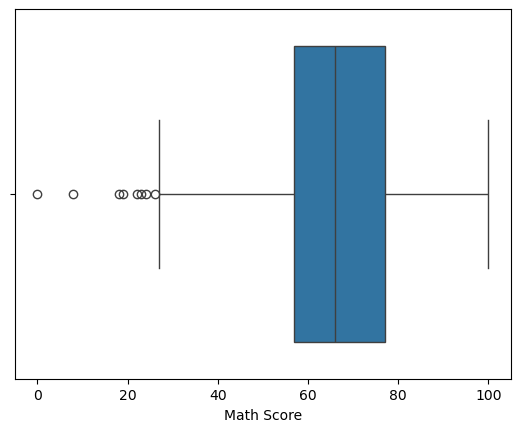

In [18]:
#TODO
sns.boxplot(data=df, x="math score")

plt.xlabel("Math Score")
plt.show()

(TASK 9): Let's take a second to discuss the properties of the boxplot (median, quartiles, outliers)

The median math score appears to be around 65. The first quartile (Q1) is approximately around 55, and the third quartile (Q3) is around 75, meaning the middle 50% of scores fall between roughly 55 and 75. The whiskers extend from about 25 to near 100, showing the overall spread of most values. There are several low outliers below about 25, indicating a few unusually low math scores. There are few to no extreme high outliers, suggesting most high scores fall within the expected range.

What about violin plots? Both are useful depending on what you want to accomplish - violin plots better show the distribution of points in an area, while box plots are better at showing outliers as individual points.

(TASK 10): Use seaborn to make a violin plot

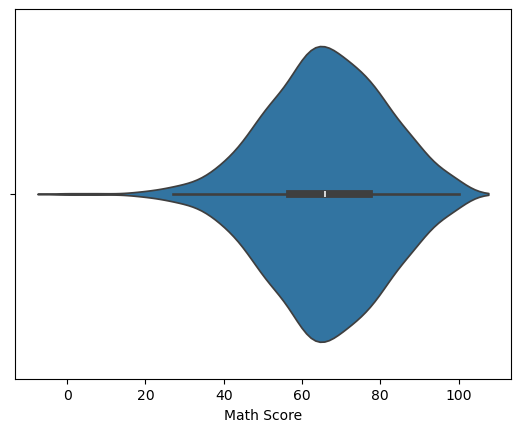

In [19]:
#TODO
sns.violinplot(data=df, x="math score")

plt.xlabel("Math Score")
plt.show()

# Scatter Plots

If you want to see if there is some type of trend between two variables, scatter plots are really useful for visualizing it. Let's see if there's a trend between math score and reading score with parental level of education as the hue.

(TASK 11): Make a scatter plot with the x axis corresponding to the math score of each student and the y axis corresponding to the reading score. Plot this scatter plot and make sure that parental level of education is somehow represented.

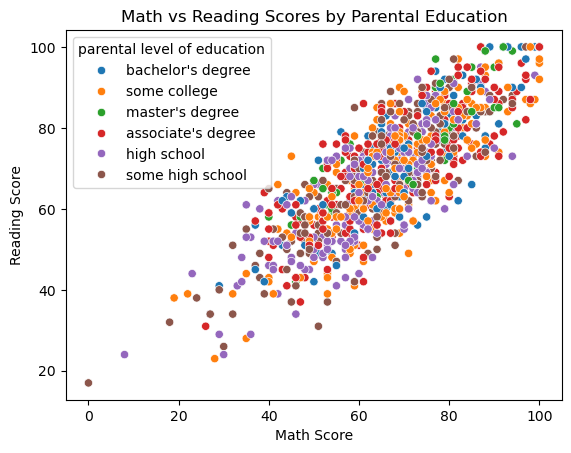

In [ ]:
#TODO
sns.scatterplot(
    data=df,
    x="math score",
    y="reading score",
    hue="parental level of education")

plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math vs Reading Scores by Parental Education")

plt.show()

It's somewhat difficult to understand exactly what's happening in this plot - this is called overfitting. To account for this, either increase the size of the graph or jitter your plot! We won't be doing this here, but keep it in mind when you need to visualize data cleanly.

What about a trend between reading score and writing score? (matplotlib does not have an option for an automatic hue)

(TASK 12): Make a scatter plot of reading and writing score like task 11 without accounting for parental education. Fit a line of best fit so we can visualize the general trend of the data on top of the scatter plot.

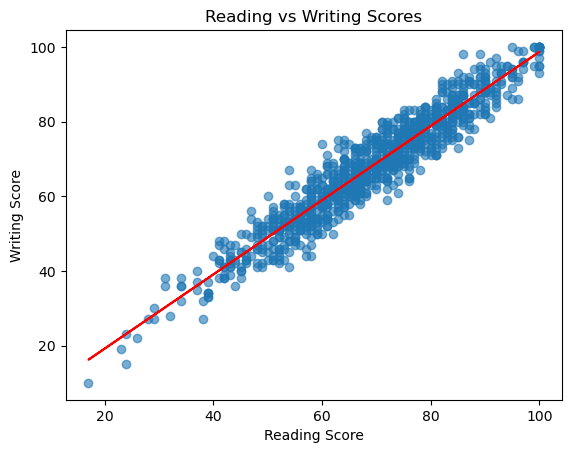

In [21]:
# Scatter plot
plt.scatter(df["reading score"], df["writing score"], alpha=0.6)

# Line of best fit
m, b = np.polyfit(df["reading score"], df["writing score"], 1)
plt.plot(df["reading score"], m*df["reading score"] + b, color="red")

# Labels
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing Scores")

plt.show()

(TASK 13): What can you compare about these two scatter plots? What information do each of these give us?

Both scatter plots show strong positive relationships. In the math vs. reading plot, higher math scores are associated with higher reading scores, and the colors show how parental education relates to performance. In the reading vs. writing plot, the points closely follow the line of best fit, showing an even stronger linear relationship between reading and writing scores.

# Transformations

### We're going to first make a new column so that there is a non-linear relationship
(TASK 14): Make a new column called "reading cubed" which is each student's reading score cubed. Plot this column instead of the regular reading score against each student's math score.

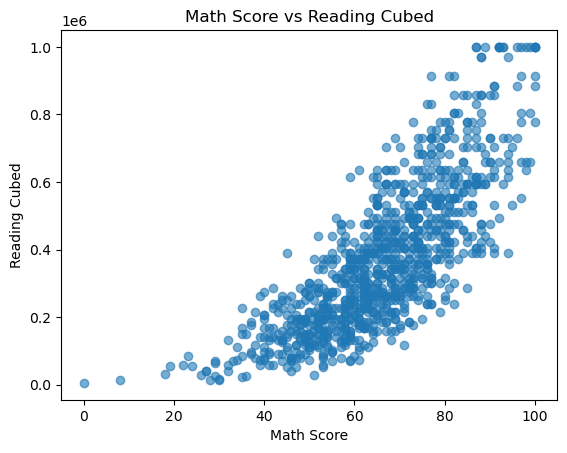

In [22]:
#TODO
df["reading cubed"] = df["reading score"] ** 3

plt.scatter(df["math score"], df["reading cubed"], alpha=0.6)

plt.xlabel("Math Score")
plt.ylabel("Reading Cubed")
plt.title("Math Score vs Reading Cubed")

plt.show()

(TASK 15): As you can see from the scatterplot, the relationship no longer looks linear. What change could we make to the math score to make a linear relationship (reference the Bulge Diagram in the slides if needed)

Create a new column that transforms the math scores so that the new column plotted against reading cubed shows a linear relationship.

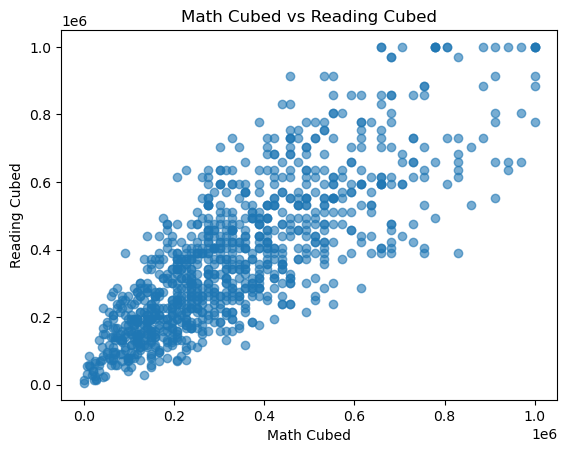

In [23]:
#TODO
df["math cubed"] = df["math score"] ** 3

plt.scatter(df["math cubed"], df["reading cubed"], alpha=0.6)

plt.xlabel("Math Cubed")
plt.ylabel("Reading Cubed")
plt.title("Math Cubed vs Reading Cubed")

plt.show()